In [4]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
 
DAVIS = Path(r"D:\Phaeron\drift\app\data_raw\DAVIS")
JPEG = Path(r"D:\Phaeron\drift\app\engine\data_raw\DAVIS\JPEGImages\480p")
ANNO = Path(r"D:\Phaeron\drift\app\engine\data_raw\DAVIS\Annotations\480p")
 
assert JPEG.exists(), f"not found: {JPEG}"
clips = sorted([d.name for d in JPEG.iterdir() if d.is_dir()])
print(f"{len(clips)} clips")
print(clips)

90 clips
['bear', 'bike-packing', 'blackswan', 'bmx-bumps', 'bmx-trees', 'boat', 'boxing-fisheye', 'breakdance', 'breakdance-flare', 'bus', 'camel', 'car-roundabout', 'car-shadow', 'car-turn', 'cat-girl', 'classic-car', 'color-run', 'cows', 'crossing', 'dance-jump', 'dance-twirl', 'dancing', 'disc-jockey', 'dog', 'dog-agility', 'dog-gooses', 'dogs-jump', 'dogs-scale', 'drift-chicane', 'drift-straight', 'drift-turn', 'drone', 'elephant', 'flamingo', 'goat', 'gold-fish', 'hike', 'hockey', 'horsejump-high', 'horsejump-low', 'india', 'judo', 'kid-football', 'kite-surf', 'kite-walk', 'koala', 'lab-coat', 'lady-running', 'libby', 'lindy-hop', 'loading', 'longboard', 'lucia', 'mallard-fly', 'mallard-water', 'mbike-trick', 'miami-surf', 'motocross-bumps', 'motocross-jump', 'motorbike', 'night-race', 'paragliding', 'paragliding-launch', 'parkour', 'pigs', 'planes-water', 'rallye', 'rhino', 'rollerblade', 'schoolgirls', 'scooter-black', 'scooter-board', 'scooter-gray', 'sheep', 'shooting', 'skat

In [5]:
rows = []
for c in clips:
  n_jpg = len(list((JPEG / c).glob("*.jpg")))
  n_png = len(list((ANNO / c).glob("*.png")))
  rows.append((c, n_jpg, n_png, "OK" if n_jpg == n_png else "MISMATCH"))
 
print(f"{'clip':<22}{'frames':>8}{'masks':>8}  status")
for c, j, p, s in rows:
  print(f"{c:<22}{j:>8}{p:>8}  {s}")
mismatches = [r for r in rows if r[3] != "OK"]
print(f"\n{len(mismatches)} mismatched clips" if mismatches else "\nall clips: frames == masks")
counts = [j for _, j, _, _ in rows]
print(f"frames per clip: min={min(counts)} max={max(counts)} mean={np.mean(counts):.1f}")

clip                    frames   masks  status
bear                        82      82  OK
bike-packing                69      69  OK
blackswan                   50      50  OK
bmx-bumps                   90      90  OK
bmx-trees                   80      80  OK
boat                        75      75  OK
boxing-fisheye              87      87  OK
breakdance                  84      84  OK
breakdance-flare            71      71  OK
bus                         80      80  OK
camel                       90      90  OK
car-roundabout              75      75  OK
car-shadow                  40      40  OK
car-turn                    80      80  OK
cat-girl                    89      89  OK
classic-car                 63      63  OK
color-run                   84      84  OK
cows                       104     104  OK
crossing                    52      52  OK
dance-jump                  60      60  OK
dance-twirl                 90      90  OK
dancing                     62      62  OK
disc-jo

In [6]:
def mask_indices(clip, frame_idx=0):
  p = sorted((ANNO / clip).glob("*.png"))[frame_idx]
  arr = np.array(Image.open(p))          # paletted -> 2D array of indices (mode 'P')
  return arr, np.unique(arr)
 
example = clips[0]
arr, vals = mask_indices(example)
print(f"clip '{example}' frame 0 mask:")
print(f"  shape={arr.shape}  dtype={arr.dtype}  unique values={vals}")
print(f"  -> {'BINARY (single object)' if set(vals.tolist()) <= {0,1} else f'MULTI-INSTANCE ({len(vals)-1} objects + bg)'}")

multi = []
for c in clips:
  _, v = mask_indices(c)
  n_obj = len([x for x in v if x != 0])
  if n_obj > 1:
    multi.append((c, n_obj))
print(f"\n{len(multi)} clips have >1 object instance:")
for c, n in multi:
  print(f"  {c}: {n} objects")
print("\nNOTE: for single-object trajectory, pick ONE instance per clip (e.g. index 1),")
print("or treat 'any nonzero' as the object if you want all instances merged.")

clip 'bear' frame 0 mask:
  shape=(480, 854)  dtype=uint8  unique values=[0 1]
  -> BINARY (single object)

57 clips have >1 object instance:
  bike-packing: 2 objects
  bmx-bumps: 2 objects
  bmx-trees: 2 objects
  boxing-fisheye: 3 objects
  cat-girl: 2 objects
  classic-car: 3 objects
  color-run: 3 objects
  crossing: 3 objects
  dancing: 3 objects
  disc-jockey: 3 objects
  dog-gooses: 5 objects
  dogs-jump: 3 objects
  dogs-scale: 4 objects
  drone: 5 objects
  gold-fish: 5 objects
  hockey: 3 objects
  horsejump-high: 2 objects
  horsejump-low: 2 objects
  india: 3 objects
  judo: 2 objects
  kid-football: 2 objects
  kite-surf: 3 objects
  kite-walk: 3 objects
  lab-coat: 5 objects
  lady-running: 2 objects
  lindy-hop: 8 objects
  loading: 3 objects
  longboard: 5 objects
  mbike-trick: 2 objects
  miami-surf: 6 objects
  motocross-bumps: 2 objects
  motocross-jump: 2 objects
  motorbike: 3 objects
  night-race: 2 objects
  paragliding: 2 objects
  paragliding-launch: 3 object

mask area fraction: min=0.002 max=0.615 mean=0.120 median=0.069


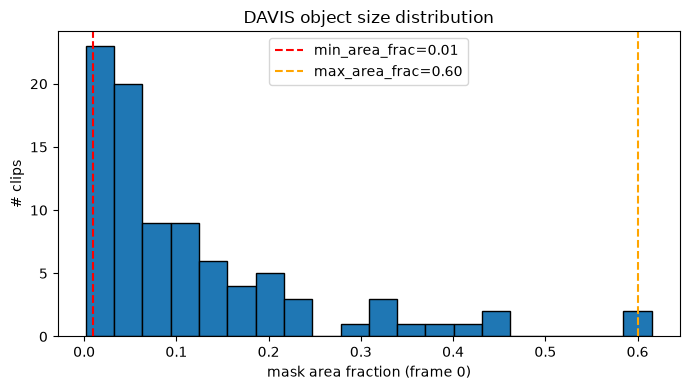

clips below 0.01: ['drift-chicane', 'motocross-bumps', 'rallye', 'skate-park']
clips above 0.60: ['tuk-tuk']


In [7]:
areas = []
for c in clips:
  arr, _ = mask_indices(c, 0)
  areas.append(float((arr > 0).mean()))
areas = np.array(areas)
print(f"mask area fraction: min={areas.min():.3f} max={areas.max():.3f} "
      f"mean={areas.mean():.3f} median={np.median(areas):.3f}")
 
plt.figure(figsize=(7, 4))
plt.hist(areas, bins=20, edgecolor="black")
plt.axvline(0.01, color="r", ls="--", label="min_area_frac=0.01")
plt.axvline(0.60, color="orange", ls="--", label="max_area_frac=0.60")
plt.xlabel("mask area fraction (frame 0)"); plt.ylabel("# clips")
plt.title("DAVIS object size distribution"); plt.legend(); plt.tight_layout()
plt.show()
# clips outside the dashed band would be filtered by your PairConfig area gates.
print("clips below 0.01:", [clips[i] for i in range(len(clips)) if areas[i] < 0.01])
print("clips above 0.60:", [clips[i] for i in range(len(clips)) if areas[i] > 0.60])

centroid displacement frame0 -> frameN (480p px), most-moving first:
  soccerball               705.7
  rollerblade              564.0
  rallye                   551.7
  motorbike                499.3
  drift-straight           475.5
  dog-agility              432.3
  scooter-gray             387.7
  kite-surf                387.0
  motocross-bumps          386.6
  stunt                    344.3
  paragliding              343.0
  scooter-black            328.3
  ...
  lady-running              17.5
  flamingo                  16.4
  loading                   12.4
  hike                      12.2
  planes-water               5.4


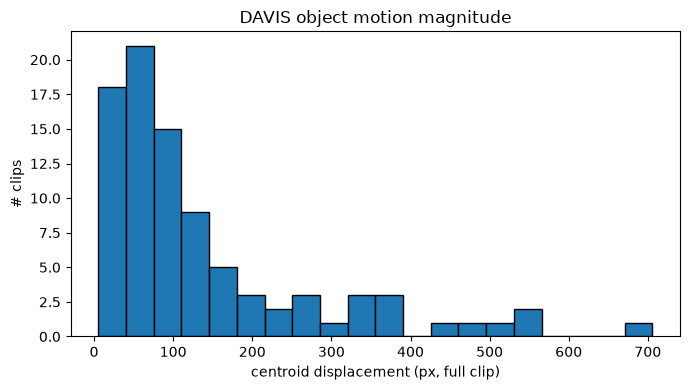

In [8]:
def centroid(arr):
  ys, xs = np.nonzero(arr > 0)
  if len(xs) == 0: return None
  return (xs.mean(), ys.mean())
 
disps = []
for c in clips:
  pngs = sorted((ANNO / c).glob("*.png"))
  a0 = np.array(Image.open(pngs[0])); aN = np.array(Image.open(pngs[-1]))
  c0, cN = centroid(a0), centroid(aN)
  if c0 and cN:
    d = ((cN[0]-c0[0])**2 + (cN[1]-c0[1])**2) ** 0.5
    disps.append((c, d))
 
disps.sort(key=lambda x: x[1], reverse=True)
print("centroid displacement frame0 -> frameN (480p px), most-moving first:")
for c, d in disps[:12]:
  print(f"  {c:<22}{d:8.1f}")
print("  ...")
for c, d in disps[-5:]:
  print(f"  {c:<22}{d:8.1f}")
dvals = np.array([d for _, d in disps])
plt.figure(figsize=(7, 4))
plt.hist(dvals, bins=20, edgecolor="black")
plt.xlabel("centroid displacement (px, full clip)"); plt.ylabel("# clips")
plt.title("DAVIS object motion magnitude"); plt.tight_layout(); plt.show()

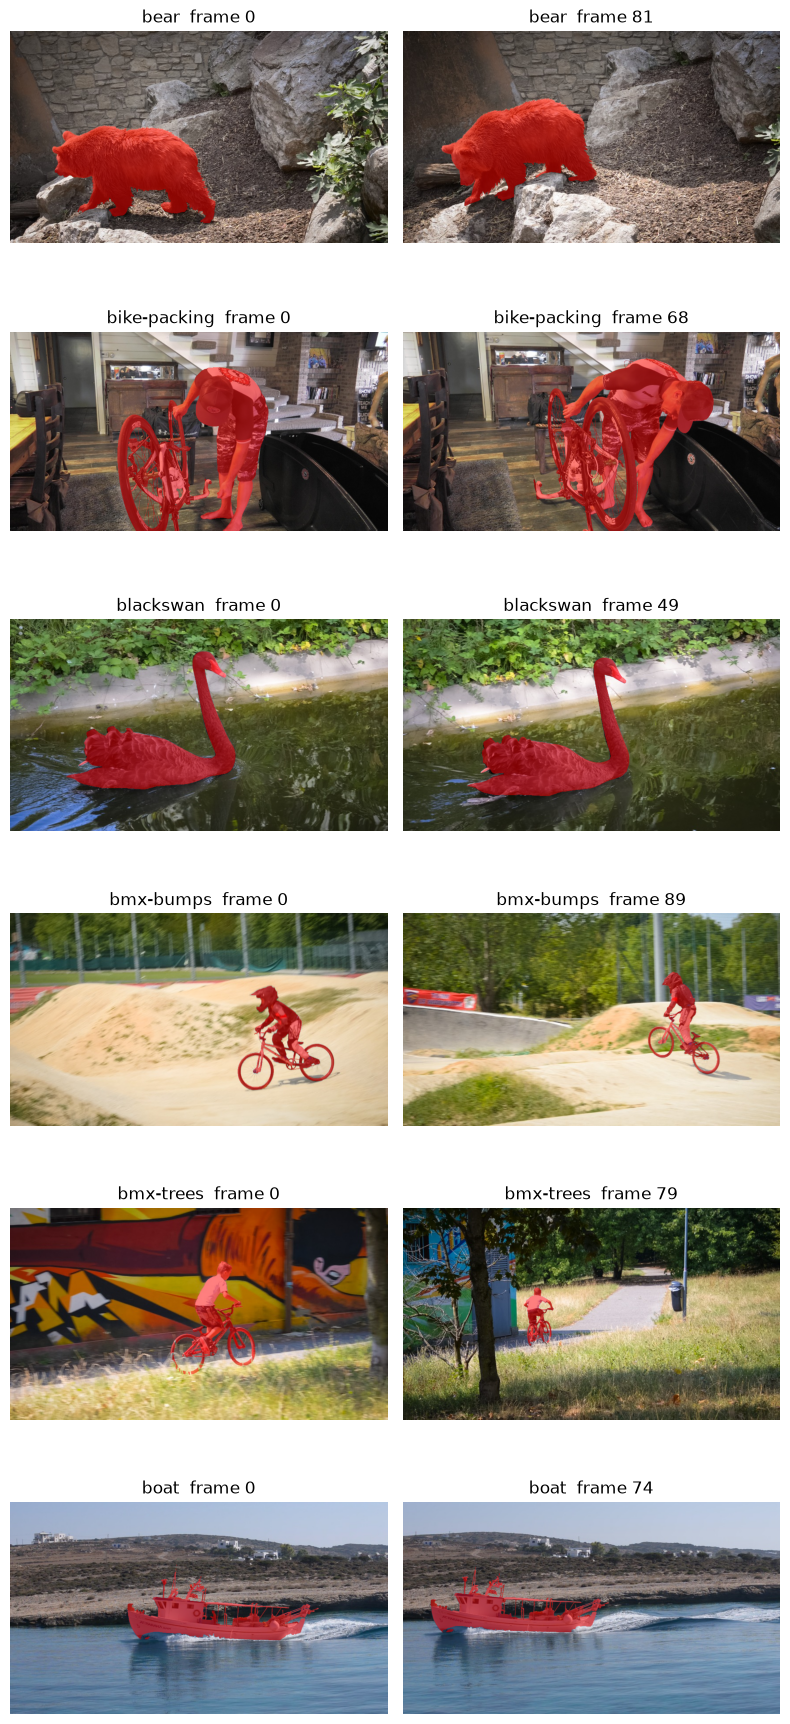

In [9]:
def overlay(clip, frame_idx):
  pngs = sorted((ANNO / clip).glob("*.png"))
  jpgs = sorted((JPEG / clip).glob("*.jpg"))
  img = np.array(Image.open(jpgs[frame_idx]).convert("RGB"))
  m = (np.array(Image.open(pngs[frame_idx])) > 0)
  out = img.copy()
  out[m] = (0.5 * out[m] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)  # red tint on object
  return out
 
sample = clips[:6]
fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3 * len(sample)))
for r, c in enumerate(sample):
  n = len(list((JPEG / c).glob("*.jpg")))
  axes[r, 0].imshow(overlay(c, 0));     axes[r, 0].set_title(f"{c}  frame 0");     axes[r, 0].axis("off")
  axes[r, 1].imshow(overlay(c, n - 1)); axes[r, 1].set_title(f"{c}  frame {n-1}"); axes[r, 1].axis("off")
plt.tight_layout(); plt.show()